In [1]:

import pandas as pd

sheet_id = '1a06tAjq1ZRYI2rkMj5Tl2YKN2KpXkZxiI9we72LfmJU'
sheet_gid = "0"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_gid}"
foods_df = pd.read_csv(url, index_col="student").drop(columns='favorite_color')
foods_df

,broccoli,brussels_sprouts,hamburger,oysters (raw),onion (raw),peas,olives,blue_cheese,whisky,age
student,,,,,,,,,,
Benno,3.0,4.0,8.0,4,6.0,4,3.0,3,5.0,21
Derek,7.0,5.0,0.0,0,5.0,7,9.0,9,9.0,37
Farnoosh,8.0,7.0,4.0,2,2.0,5,9.0,9,8.0,35
Kwabena,8.5,5.5,7.5,5,6.5,8,8.5,5,9.5,33
Oleksandra,8.0,8.0,5.0,0,8.0,5,10.0,5,5.0,50
Sanaz,7.0,5.0,4.0,0,1.0,9,10.0,5,3.0,44
Mersiha,8.0,8.0,9.0,0,0.0,10,10.0,5,0.0,93


####Exercise 1: Import a scaler and initialize it

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### Here I import the StandardScaler from sklearn and initialize the scaler object so it can later be used to scale the dataset.

#####Hint:

Google "sklearn [the scaler you want to use]" to find the scaler's documentation<br>
At the very top it says `class sklearn.______.______(`... This is kind of like a file path telling us where to find the model in the library. So to import it we run `from sklearn.______ import ______`.<br><br>
To initialize the scaler we call it like a function and assign the result to a variable: `scaler = ______()`

####Exercise 2: Scale the food data using your scaler

In [3]:
scaled_features = scaler.fit_transform(foods_df)

### Here I used the scaler to scale the food dataset. The fit_transform() function learns the scaling parameters from the data and applies the transformation.

#####Hint:

`scaled_data = scaler.fit_transform(data)`

####Exercise 3: Initialize a K-means model and fit it to the scaled data

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_features)

KMeans(n_clusters=3, random_state=42)

### I chose n_clusters = 3 as an initial value to group the students into three possible food preference groups.

#####Hint:

```
model = _________(n_clusters=____)
model.fit(scaled_data)
```

####Exercise 4: Extract the labels from the fit model, add them to the original data frame, and sort it by the cluster assignments to more easily see the groupings

In [5]:
# extract cluster labels
foods_df["cluster"] = kmeans.labels_

# sort dataframe by cluster
foods_df_sorted = foods_df.sort_values("cluster")

foods_df_sorted

,broccoli,brussels_sprouts,hamburger,oysters (raw),onion (raw),peas,olives,blue_cheese,whisky,age,cluster
student,,,,,,,,,,,
Derek,7.0,5.0,0.0,0,5.0,7,9.0,9,9.0,37,0
Farnoosh,8.0,7.0,4.0,2,2.0,5,9.0,9,8.0,35,0
Kwabena,8.5,5.5,7.5,5,6.5,8,8.5,5,9.5,33,0
Oleksandra,8.0,8.0,5.0,0,8.0,5,10.0,5,5.0,50,0
Mersiha,8.0,8.0,9.0,0,0.0,10,10.0,5,0.0,93,1
Sanaz,7.0,5.0,4.0,0,1.0,9,10.0,5,3.0,44,1
Benno,3.0,4.0,8.0,4,6.0,4,3.0,3,5.0,21,2


### I extracted the cluster labels from the fitted K-Means model and added them as a new column to the original dataset. Then I sorted the dataframe by the cluster column to clearly see which students belong to the same group.


### The clustering results show three groups of students with different food preferences and age patterns.

### Cluster 0 contains students between 33-50, who have balanced preferences and relatively high ratings for vegetables and olives.

### Cluster 1 includes 2 persons with 44 and 93 years old, who strongly prefer vegetables like peas and olives but have low preference for hamburgers.

### Cluster 2 contains only one student, the youngest participant, who shows a stronger preference for hamburgers and lower preference for vegetables.

#####Hint:

Extract a list of cluster assignments from the model using `model.labels_`<br><br>
`df.sort_values()`

####Exercise 5: Get the inertia and silhouette score of the results

In [6]:
from sklearn.metrics import silhouette_score

# get inertia
inertia = kmeans.inertia_

# get silhouette score
sil_score = silhouette_score(scaled_features, kmeans.labels_)

print("Inertia:", inertia)
print("Silhouette score:", sil_score)

Inertia: 27.20928197184643
Silhouette score: 0.1682816010003107


### I calculated the inertia and silhouette score of the K-Means model. Inertia measures how close the data points are to their cluster centers, while the silhouette score evaluates how well the clusters are separated.

### The silhouette score is relatively low, indicating that the clusters overlap to some extent. This may be due to the small dataset size and the similarity of food preferences among students.

#####Hint:

Check [the attributes section of the KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#:~:text=instead%20of%20%E2%80%9Celkan%E2%80%9D.-,Attributes%3A,-cluster_centers_ndarray%20of) to see where you can get the model's labels and the inertia score.
<br><br>
Check [the silhouette score documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) to see where you need to import the function from and what you need to input into it
```
from sklearn.________ import silhouette_score
sscore = silhouette_score(_____, ______)
```

#### Bonus: Write a loop to get the inertia and silhouette scores for different values of k (try a range from 2 to 7)

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,7):   # try k = 2,3,4,5
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)

    inertia = kmeans.inertia_
    sil = silhouette_score(scaled_features, kmeans.labels_)

    scores.append({
        "k": k,
        "inertia": inertia,
        "sil_score": sil
    })

# create dataframe for plotting
scores_df = pd.DataFrame(scores)

scores_df

,k,inertia,sil_score
0,2,54.324642,0.100943
1,3,27.209282,0.168282
2,4,20.216098,0.023969
3,5,12.967547,0.007124
4,6,6.677458,-0.027674


### Although inertia decreases as k increases, the silhouette score is highest at k = 3. This indicates that using three clusters provides the best balance between compact and well-separated clusters for the food preference dataset.

##### Hint:

Bonus Bonus: Plot the inertia and silhouette scores to decide on a number of clusters

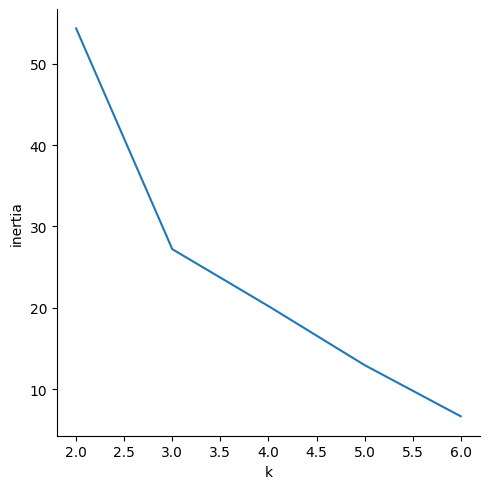

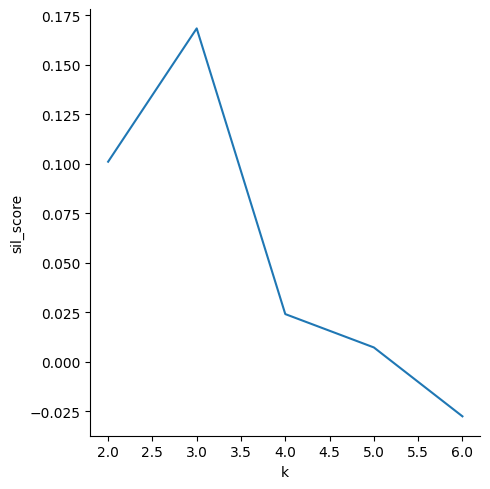

In [8]:
import seaborn as sns

sns.relplot(
    kind="line",
    data=scores_df,
    x="k",
    y="inertia"
)

sns.relplot(
    kind="line",
    data=scores_df,
    x="k",
    y="sil_score"
)

### I computed inertia and silhouette scores for different values of k and stored the results in a dataframe. Then I plotted the values to visually compare the clustering performance.

## Inertia plot

## In the first plot, inertia decreases as the number of clusters increases. This is expected because more clusters mean that data points are closer to their cluster centers. The biggest drop happens between k = 2 and k = 3.

## Silhouette plot

### The silhouette score measures how well the clusters are separated. The highest silhouette score appears at k = 3, which means the clusters are most clearly separated at this value.

# Based on both plots, k = 3 seems to be the best number of clusters for this dataset.

#### Hint:

```
sns.relplot(
    kind='line',
    data=scores_df,
    x='k',
    y='inertia'
)
```

```
sns.relplot(
    kind='line',
    data=scores_df,
    x='k',
    y='sil_score'
)
```